In [1]:
from keras import Sequential
from keras.layers import Dense,SimpleRNN

In [2]:
model = Sequential()
model.add(SimpleRNN(3,input_shape=(4,5)))
model.add(Dense(1,activation='sigmoid'))
model.summary()

f:\Python\Deep-Learning-and-Computer-vision\deepenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris


In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()

In [ ]:
x = iris.data
y = iris.target

In [ ]:
x = pd.DataFrame(x)
y = pd.DataFrame(y)

In [ ]:
x = x.iloc[:,:2]

In [ ]:
x.head()

,0,1
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [ ]:
p = Perceptron()
p.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Perceptron()

In [ ]:
p.coef_ #will depend on number of class * features

array([[-33. ,  50.2],
       [ 13.8, -29.3],
       [ 17. , -34.3]])

In [ ]:
p.intercept_

array([ 13.,  15., -29.])

<Axes: >

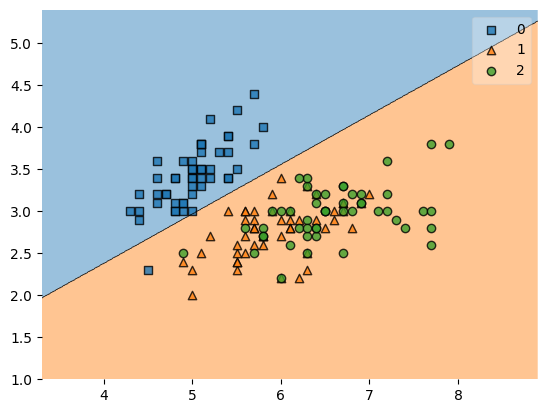

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values,y.values.ravel(),p)

In [ ]:
from sklearn.datasets import make_classification
x,y = make_classification(n_samples=100, n_features= 2, n_informative=1, n_classes=2, n_redundant=0, random_state=41, n_clusters_per_class=1, class_sep=0.5)

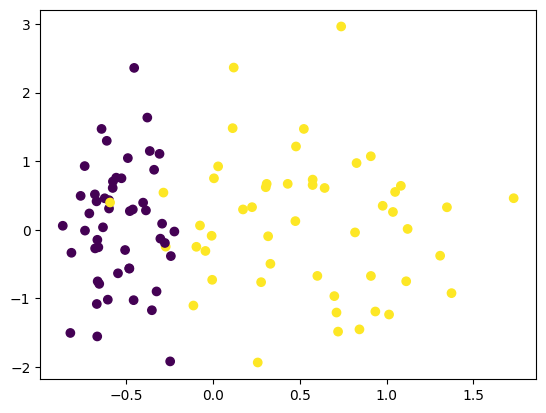

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y)

In [ ]:
def perceptron(x,y):
  x = np.insert(x,0,1,axis=1)
  weights = np.random.rand(x.shape[1])
  lr = 0.01
  epoch = 100

  for i in range(epoch):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(x[j],weights))
    weights = weights + lr* (y[j]-y_hat)*x[j]

  return weights[0],weights[1:]

In [ ]:
def step(z):
  return 1 if z > 0 else 0

In [ ]:
coef_,intercept_ = perceptron(x,y)

In [ ]:
print(coef_)
print(intercept_)

0.16432629448977154
[0.56124642 0.14346488]


for loss function

In [ ]:
def perceotron(x,y):
  w1,w2,b=1
  lr = 0.1

  for j in range(1000):
    for i in range(x.shape[0]):

      z = w1*x[i][0] + w2*x[i][1] + b
      if z*y[i]<=0:
        w1 = w1 - lr*y[i] * x[i][0]
        w2 = w2 - lr*y[i] * x[i][1]
        b = b - lr*y[i]

  return w1,w2,b